# Task & Solution EDA

Exploratory analysis of task descriptions and verifier structure across all dataset versions.

In [1]:
import re
import tomllib
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams['figure.dpi'] = 120
plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
TASKS_DIR = Path('../harbor_tasks_8192_deduped')

DATASET_DIRS = [
    TASKS_DIR / 'harbor_4.5opus_tasks' / 'harbor_tasks_claude4.5_opus' / 'harbor_tasks_part2_2-1',
    TASKS_DIR / 'harbor_4.5opus_tasks' / 'harbor_tasks_claude4.5_opus' / 'harbor_tasks_part2_2-2',
    TASKS_DIR / 'harbor_4.5opus_tasks' / 'harbor_tasks_claude4.5_opus' / 'harbor_tasks_part2_2-3',
    TASKS_DIR / 'harbor_4.6opus_tasks_8192_part1-2' / 'harbor_tasks_8192',
    TASKS_DIR / 'harbor_4.6opus_tasks_8192_part1-2' / 'harbor_tasks_8192_part2',
    TASKS_DIR / 'harbor_4.8opus_tasks_v3',
]

## 1. Load Task Data

In [3]:
def load_tasks(dataset_dirs, max_per_dir=None):
    rows = []
    seen = set()
    for dataset_dir in dataset_dirs:
        if not dataset_dir.exists():
            continue
        count = 0
        for task_dir in sorted(dataset_dir.iterdir()):
            if not task_dir.is_dir() or not task_dir.name.startswith('task_'):
                continue
            if task_dir.name in seen:
                continue
            seen.add(task_dir.name)

            toml_path = task_dir / 'task.toml'
            instruction_path = task_dir / 'instruction.md'
            test_path = task_dir / 'tests' / 'test_final_state.py'

            if not toml_path.exists() or not instruction_path.exists():
                continue

            with open(toml_path, 'rb') as f:
                meta = tomllib.load(f).get('metadata', {})

            description = instruction_path.read_text(errors='replace')
            test_code = test_path.read_text(errors='replace') if test_path.exists() else ''
            num_test_funcs = len(re.findall(r'def test_', test_code))

            rows.append({
                'task_id':         task_dir.name,
                'difficulty':      meta.get('difficulty', 'unknown'),
                'description_len': len(description),
                'num_test_funcs':  num_test_funcs,
            })
            count += 1
            if max_per_dir and count >= max_per_dir:
                break
    return pd.DataFrame(rows)

# Sample up to 500 tasks per directory for fast loading (~10s total)
df = load_tasks(DATASET_DIRS, max_per_dir=500)
print(f'Loaded {len(df):,} tasks')
print(df['difficulty'].value_counts().to_string())

Loaded 3,000 tasks
difficulty
medium    2171
easy       574
hard       255


## 2. Description Length Distribution

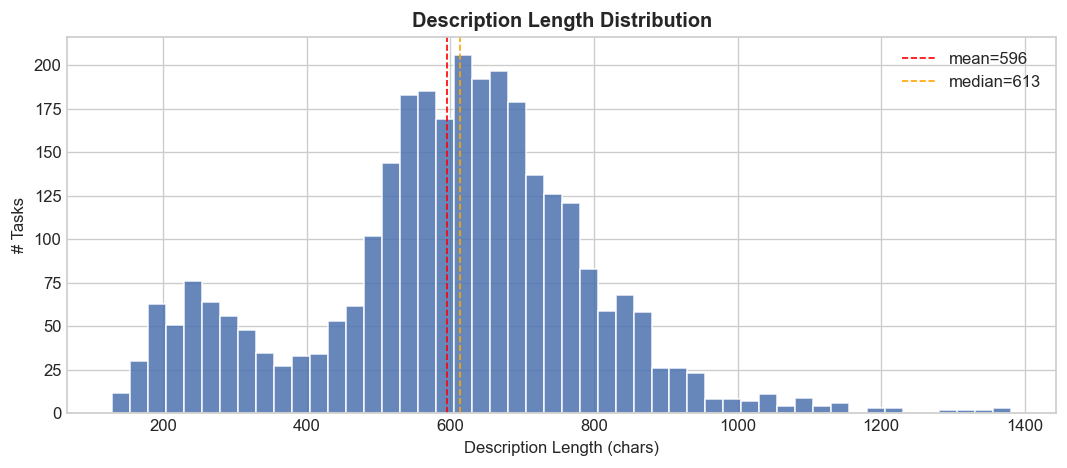

count    3000.0
mean      595.6
std       195.6
min       129.0
25%       506.0
50%       613.0
75%       713.0
max      1381.0


In [4]:
fig, ax = plt.subplots(figsize=(9, 4))

ax.hist(df['description_len'], bins=50, color='#4C72B0', edgecolor='white', alpha=0.85)
ax.axvline(df['description_len'].mean(), color='red', linestyle='--', linewidth=1,
           label=f'mean={df["description_len"].mean():.0f}')
ax.axvline(df['description_len'].median(), color='orange', linestyle='--', linewidth=1,
           label=f'median={df["description_len"].median():.0f}')
ax.set_xlabel('Description Length (chars)')
ax.set_ylabel('# Tasks')
ax.set_title('Description Length Distribution', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.show()

print(df['description_len'].describe().round(1).to_string())

## 3. Test Function Count by Difficulty

/var/folders/hw/2q_93jjj2hv_zl2qwvfcfzhc0000gn/T/ipykernel_31180/207290626.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(groups, labels=present, patch_artist=True,


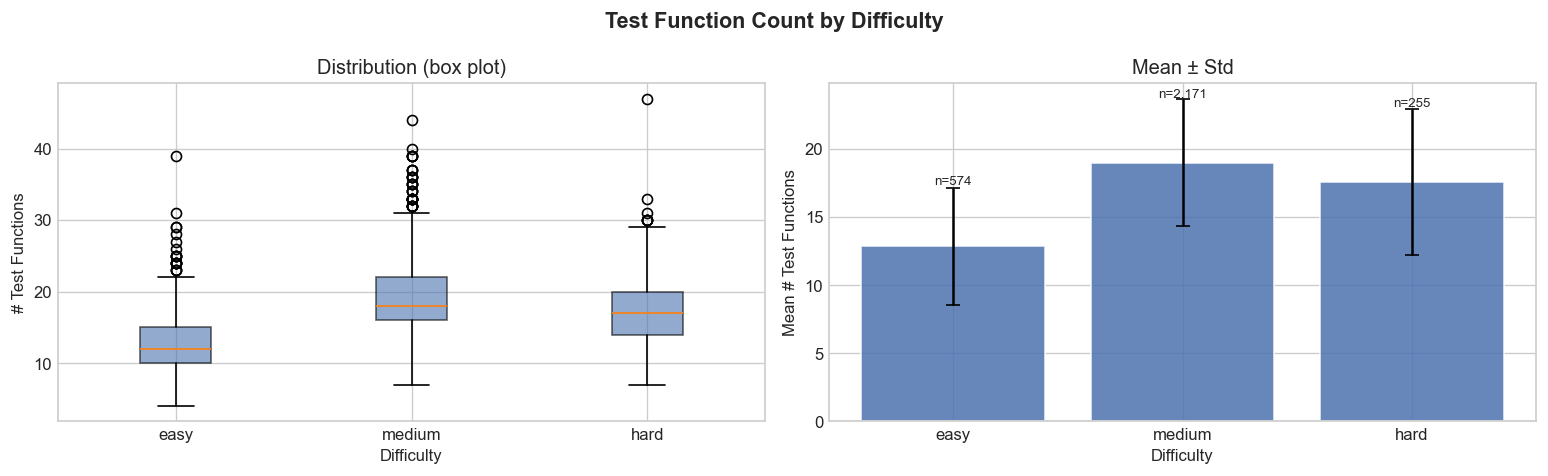

             count   mean   std  min   25%   50%   75%   max
difficulty                                                  
easy         574.0  12.84  4.31  4.0  10.0  12.0  15.0  39.0
medium      2171.0  18.99  4.65  7.0  16.0  18.0  22.0  44.0
hard         255.0  17.56  5.34  7.0  14.0  17.0  20.0  47.0
intricate      NaN    NaN   NaN  NaN   NaN   NaN   NaN   NaN


In [5]:
difficulty_order = ['easy', 'medium', 'hard', 'intricate']
df_plot = df[df['difficulty'].isin(difficulty_order)].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Test Function Count by Difficulty', fontsize=13, fontweight='bold')

# Left: box plot
groups = [df_plot[df_plot['difficulty'] == d]['num_test_funcs'].values for d in difficulty_order
          if d in df_plot['difficulty'].values]
present = [d for d in difficulty_order if d in df_plot['difficulty'].values]
axes[0].boxplot(groups, labels=present, patch_artist=True,
                boxprops=dict(facecolor='#4C72B0', alpha=0.6))
axes[0].set_xlabel('Difficulty')
axes[0].set_ylabel('# Test Functions')
axes[0].set_title('Distribution (box plot)')

# Right: mean std bar chart
stats = (df_plot.groupby('difficulty')['num_test_funcs']
         .agg(['mean', 'std'])
         .reindex(difficulty_order)
         .dropna())
axes[1].bar(stats.index, stats['mean'], yerr=stats['std'], capsize=4,
            color='#4C72B0', edgecolor='white', alpha=0.85)
axes[1].set_xlabel('Difficulty')
axes[1].set_ylabel('Mean # Test Functions')
axes[1].set_title('Mean ± Std')
for i, (idx, row) in enumerate(stats.iterrows()):
    n = (df_plot['difficulty'] == idx).sum()
    axes[1].text(i, row['mean'] + row['std'] + 0.2, f'n={n:,}', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

print(df_plot.groupby('difficulty')['num_test_funcs'].describe().round(2).reindex(difficulty_order).to_string())

## 4. Fine-grained Category Pass Rate

> To be completed once eval results are available.